<a href="https://colab.research.google.com/github/SureshGopiPROLITE/PLC_DATA/blob/Main/MotorAnomalyPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

### Charts ###
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# prompt: connect drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('//content//drive//My Drive//Mydata//MLP/Motor Anomaly Prediction//DataSet_Motor_21.08.2024_3.xlsx')
df.head()

,Id,TimeStamp,Name,Category,DataType,Value
0,114023,2024-08-21 14:11:04.136,MotorA_RunFbk,MotorA,BOOL,1.00
1,114024,2024-08-21 14:11:04.145,MotorA_Speed,MotorA,REAL,50.00
2,114025,2024-08-21 14:11:04.147,MotorA_Speed%,MotorA,REAL,99.99
3,114026,2024-08-21 14:11:04.151,MotorA_Current,MotorA,REAL,84.41
4,114027,2024-08-21 14:11:04.162,MotorA_Current%,MotorA,REAL,25.60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15570 entries, 0 to 15569
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         15570 non-null  int64  
 1   TimeStamp  15570 non-null  object 
 2   Name       15570 non-null  object 
 3   Category   15570 non-null  object 
 4   DataType   15570 non-null  object 
 5   Value      15570 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 730.0+ KB


In [ ]:
df1 = df.drop(['Id', 'DataType'], axis=1)
df1['TimeStamp'] = pd.to_datetime(df1['TimeStamp'])

# Remove milliseconds by flooring to the nearest second
df1['TimeStamp'] = df1['TimeStamp'].dt.floor('s')

In [ ]:
df1.head()

,TimeStamp,Name,Category,Value
0,2024-08-21 14:11:04,MotorA_RunFbk,MotorA,1.00
1,2024-08-21 14:11:04,MotorA_Speed,MotorA,50.00
2,2024-08-21 14:11:04,MotorA_Speed%,MotorA,99.99
3,2024-08-21 14:11:04,MotorA_Current,MotorA,84.41
4,2024-08-21 14:11:04,MotorA_Current%,MotorA,25.60


In [ ]:
def NameSplit(Name):
  Name = Name.split("_")
  return Name[1]

In [ ]:
df1['Name'] = df1['Name'].apply(NameSplit)

In [ ]:
df1

,TimeStamp,Name,Category,Value
0,2024-08-21 14:11:04,RunFbk,MotorA,1.00
1,2024-08-21 14:11:04,Speed,MotorA,50.00
2,2024-08-21 14:11:04,Speed%,MotorA,99.99
3,2024-08-21 14:11:04,Current,MotorA,84.41
4,2024-08-21 14:11:04,Current%,MotorA,25.60
...,...,...,...,...
15565,2024-08-21 15:23:03,Current%,MotorB,0.03
15566,2024-08-21 15:23:03,Torque,MotorB,0.00
15567,2024-08-21 15:23:03,Torque%,MotorB,0.00
15568,2024-08-21 15:23:03,kW,MotorB,0.00


In [ ]:
def UpdateCollectionId(df1):
  Cid =0
  for i in range(len(df1)):
    if (df1.loc[i, "Name"] == 'RunFbk') :
      Cid += 1
    df1.loc[i,'CollectionId'] = Cid

In [ ]:
UpdateCollectionId(df1)

In [ ]:
df1.tail()

,TimeStamp,Name,Category,Value,CollectionId
15565,2024-08-21 15:23:03,Current%,MotorB,0.03,1730.0
15566,2024-08-21 15:23:03,Torque,MotorB,0.00,1730.0
15567,2024-08-21 15:23:03,Torque%,MotorB,0.00,1730.0
15568,2024-08-21 15:23:03,kW,MotorB,0.00,1730.0
15569,2024-08-21 15:23:03,kW%,MotorB,0.00,1730.0


In [ ]:
df_pivot = df1.pivot(index='CollectionId', columns='Name', values='Value')
df_pivot.head()

Name,Current,Current%,RunFbk,Speed,Speed%,Torque,Torque%,kW,kW%
CollectionId,,,,,,,,,
1.0,84.41,25.60,1.0,50.0,99.99,94.24,11.06,44.74,22.36
2.0,84.62,25.63,1.0,50.0,99.99,94.35,11.06,44.73,22.36
3.0,83.96,25.44,1.0,50.0,99.99,94.32,11.07,44.41,22.20
4.0,83.66,25.35,1.0,50.0,99.99,93.57,10.95,44.26,22.13
5.0,84.26,25.53,1.0,50.0,99.99,94.39,11.07,44.67,22.29


In [ ]:
df_pivot.isnull().sum()

,0
Name,
Current,0
Current%,0
RunFbk,0
Speed,0
Speed%,0
Torque,0
Torque%,0
kW,0
kW%,0


In [ ]:
df_pivot.shape

(1730, 9)

In [ ]:
df_pivot.nunique()

,0
Name,
Current,413
Current%,383
RunFbk,2
Speed,2
Speed%,2
Torque,497
Torque%,371
kW,557
kW%,375


In [ ]:
df_pivot = df_pivot.drop(["RunFbk", "Speed", "Speed%", 'Current%', 'Torque%', 'kW%'], axis=1)

In [ ]:
# Filter the DataFrame to drop rows where any of the specified columns contain 0
df_filtered = df_pivot[(df_pivot[['Torque']] != 0).all(axis=1)]
df_filtered

Name,Current,Torque,kW
CollectionId,,,
1.0,84.41,94.24,44.74
2.0,84.62,94.35,44.73
3.0,83.96,94.32,44.41
4.0,83.66,93.57,44.26
5.0,84.26,94.39,44.67
...,...,...,...
1694.0,83.57,91.69,44.27
1695.0,82.84,90.57,43.84
1696.0,82.78,91.38,43.81


In [ ]:
features = df_filtered.select_dtypes(include=[float, int])

# Step 5: Normalize/Scale the Data
SS = StandardScaler()
SS.fit(features)
features_scaled = SS.transform(features)

In [ ]:
# Step 6: Split the Data into Training and Testing Sets
X_train, X_test = train_test_split(features_scaled, test_size=0.05, random_state=42)

# Step 7: Model Building
model = IsolationForest(n_estimators=10, contamination='auto', random_state=42)

# Step 8: Model Training
model.fit(X_train)



IsolationForest(n_estimators=10, random_state=42)

In [ ]:
# Step 9: Evaluate the Model
# Predicting anomalies in the test set
predictions = model.predict(X_test)

# -1 for anomalies, 1 for normal
anomalies = X_test[predictions == -1]

print("Number of anomalies detected:", len(anomalies))
print("Number of anomalies detected in %:", (len(anomalies)/X_test.shape[0])*100.0)

Number of anomalies detected: 23
Number of anomalies detected in %: 27.058823529411764


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
# Define a custom scoring function or use one of the available scorers like ROC AUC
def custom_scorer(estimator, X):
    # Using decision function scores for ranking anomalies (higher scores indicate inliers)
    scores = estimator.decision_function(X)
    return scores.mean()  # Custom logic to evaluate the performance

scorer = make_scorer(custom_scorer, greater_is_better=True)
# Initialize Isolation Forest
isolation_forest = IsolationForest()
# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_samples': [128, 256, 512],
    'contamination': [0.01, 0.05, 0.1, 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    'max_features': [1.0],
}

# Grid search (no target needed)
grid_search = GridSearchCV(estimator=isolation_forest, param_grid=param_grid, scoring=custom_scorer,  cv=3)
grid_search.fit(X_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Outlier scores
outlier_scores = grid_search.best_estimator_.decision_function(X_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
108 fits failed out of a total of 297.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 727, in _fit_and_score
    estimator.fit(X_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_param_v

Best parameters: {'contamination': 0.01, 'max_features': 1.0, 'max_samples': 128, 'n_estimators': 500}


In [ ]:
X_test.shape[0]

85

In [ ]:
df4Test = pd.read_excel("/content/DF4_test_2.xlsx")
# df4Test.head()
# Assuming df is your DataFrame
df4Test = df4Test.head(90)
df4Test.shape

(90, 6)

In [ ]:
df4Test.loc[3, 'Value'] = 84.0

In [ ]:
df4Test

,Id,TimeStamp,Name,Category,DataType,Value
0,114023,2024-08-21 14:11:04.136,MotorA_RunFbk,MotorA,BOOL,1.00
1,114024,2024-08-21 14:11:04.145,MotorA_Speed,MotorA,REAL,50.00
2,114025,2024-08-21 14:11:04.147,MotorA_Speed%,MotorA,REAL,99.99
3,114026,2024-08-21 14:11:04.151,MotorA_Current,MotorA,REAL,84.00
4,114027,2024-08-21 14:11:04.162,MotorA_Current%,MotorA,REAL,25.60
...,...,...,...,...,...,...
85,114108,2024-08-21 14:11:23.964,MotorB_Current%,MotorB,REAL,25.44
86,114109,2024-08-21 14:11:23.966,MotorB_Torque,MotorB,REAL,94.04
87,114110,2024-08-21 14:11:23.969,MotorB_Torque%,MotorB,REAL,11.02
88,114111,2024-08-21 14:11:23.971,MotorB_kW,MotorB,REAL,54.00


In [ ]:
df4Test['Name'] = df4Test['Name'].apply(NameSplit)
UpdateCollectionId(df4Test)
df4_pivot = df4Test.pivot(index='CollectionId', columns='Name', values='Value')
df4_pivot = df4_pivot.drop(["RunFbk", "Speed", "Speed%", 'Current%', 'Torque%', 'kW%'], axis=1)
df4_pivot.head()


Name,Current,Torque,kW
CollectionId,,,
1.0,504.00,94.24,44.74
2.0,84.62,160.00,44.73
3.0,83.96,94.32,86.00
4.0,83.66,93.57,44.26
5.0,84.26,94.39,44.67


In [ ]:
df4_pivot.loc[3, 'kW'] = 49

In [ ]:
testfeatures = df4_pivot.select_dtypes(include=[float, int])
X_testData = SS.transform(testfeatures)

In [ ]:
X_testData

array([[-0.85095822, -0.86073431, -0.80066687],
       [-0.7932188 , -0.86868413, -0.80235764],
       [-0.85468334, -0.85808437,  6.17546442],
       [-0.88262177, -0.88292755, -0.88182399],
       [-0.82674491, -0.85576567, -0.81250228],
       [-0.86585871, -1.26617508, -0.86660703],
       [-0.82953876, -3.31987832, -0.83110079],
       [-0.82674491, -0.88822743, -0.81419305],
       [-0.83792029, -0.85046579, -0.82095615],
       [-0.85468334, -0.86735916,  0.76498936]])

In [ ]:
# Predicting anomalies in the test set
predictions1 = model.predict(X_testData)

# -1 for anomalies, 1 for normal
anomalies1 = X_testData[predictions1 == -1]

print("Number of anomalies detected:", len(anomalies1))
print("Number of anomalies detected in %:", (len(anomalies1)/X_testData.shape[0])*100.0)
print(predictions1)

Number of anomalies detected: 4
Number of anomalies detected in %: 40.0
[ 1  1 -1  1  1 -1 -1  1  1 -1]


In [ ]:
#Get anomally score
anomaly_score = model.decision_function(X_testData)
anomaly_score

array([ 0.05258141,  0.05160921, -0.02457073,  0.02738426,  0.06424662,
       -0.04698648, -0.01351314,  0.07882929,  0.07990479, -0.03194035])

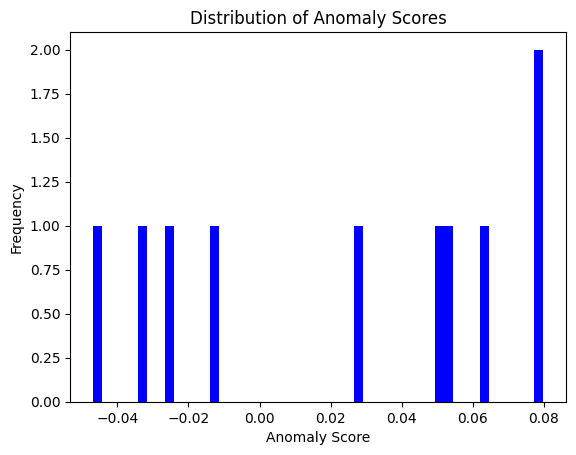

In [ ]:
plt.hist(anomaly_score, bins=50, color='blue')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.title('Distribution of Anomaly Scores')
plt.show()

In [ ]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 14.0 MB/s eta 0:00:00


In [ ]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_testData)
shap_values

array([[ 0.53228064,  0.21478996,  0.16392455],
       [ 0.08207788,  0.32422027,  0.47261605],
       [ 0.10482728, -0.2761147 , -1.26901645],
       [-0.58740172,  0.33743935,  0.35118535],
       [ 0.60482373,  0.11887251,  0.57776158],
       [ 0.00993128, -2.11028092,  0.04159092],
       [-0.05027144, -1.73744386,  0.66229612],
       [ 0.62947749,  0.61991784,  0.5551497 ],
       [ 0.87919518,  0.15639022,  0.80675026],
       [ 0.14543752, -0.18641862, -1.60552095]])

In [ ]:
df4_pivot

Name,Current,Torque,kW
CollectionId,,,
1.0,84.00,94.24,44.74
2.0,84.62,94.00,44.73
3.0,83.96,94.32,49.00
4.0,83.66,93.57,44.26
5.0,84.26,94.39,44.67
6.0,83.84,82.00,44.35
7.0,84.23,20.00,44.56
8.0,84.26,93.41,44.66
9.0,84.14,94.55,44.62


In [ ]:
import numpy as np

# Initialize an array of size 1730 with all elements set to 1
y_actual = np.ones(10)

# Set the first 10 elements to -1
y_actual[:10] = -1

# Display the array
print(y_actual)

[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]


In [ ]:
# Predict and evaluate
accuracy = accuracy_score(y_actual, predictions1)
report = classification_report(y_actual, predictions1)
# cm = confusion_matrix(y_actual, predictions, labels=model.classes_)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm,
#                               display_labels=model.classes_)

print(accuracy)
print(report)
# disp.plot()
# plt.show()

0.0
              precision    recall  f1-score   support

        -1.0       0.00      0.00      0.00      10.0
         1.0       0.00      0.00      0.00       0.0

    accuracy                           0.00      10.0
   macro avg       0.00      0.00      0.00      10.0
weighted avg       0.00      0.00      0.00      10.0



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.